In [1]:
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Bidirectional, Dense, Dropout,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model

Arabic normalization

In [2]:
def normalize_arabic(text):
    text = str(text)

    # Remove tashkeel
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)

    # Normalize Alef
    text = re.sub(r'[إأآا]', 'ا', text)

    # Normalize Ya
    text = re.sub(r'ى', 'ي', text)

    # Normalize Ta Marbuta
    text = re.sub(r'ة', 'ه', text)

    # Remove punctuation except Arabic/English letters and numbers
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [12]:
def load_qa_json(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    rows = []
    for article in raw.get("data", []):
        for paragraph in article.get("paragraphs", []):
            context = paragraph.get("context", "")
            for qa in paragraph.get("qas", []):
                question = qa.get("question", "")
                answers = qa.get("answers", [])
                answer_text = answers[0].get("text", "") if answers else ""

                rows.append({
                    "id": qa.get("id", ""),
                    "question": question,
                    "context": context,
                    "answer": answer_text
                })

    return rows

DATASET_DIR = "data_MS2"

train_rows = []
test_rows = []

for file in os.listdir(DATASET_DIR):
    if file.endswith(".json"):
        file_path = os.path.join(DATASET_DIR, file)

        if "test_set" in file:
            test_rows.extend(load_qa_json(file_path))
        elif "qa_dataset" in file:
            train_rows.extend(load_qa_json(file_path))

df = pd.DataFrame(train_rows)
test_df = pd.DataFrame(test_rows)

df = df.copy()

print("Training samples:", len(df))
print("Testing samples:", len(test_df))

df.head()

Training samples: 168
Testing samples: 72


,id,question,context,answer
0,Q1,ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخول...,في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن ع...,تمثيلية إذاعية عن غزو فضائي
1,Q2,ما الرواية التي استندت إليها التمثيلية الإذاعية؟,بعد الذعر الجماهيري، اكتشف الناس أن القصة مقتب...,حرب العوالم
2,Q3,لماذا اهتمت هوليوود بأورسون ويلز؟,لاحظت هوليوود أن ويلز استطاع التأثير على ملايي...,قدرته على التأثير في مشاعر الجمهور باستخدام الصوت
3,Q4,ما طبيعة أفلام هوليوود قبل Citizen Kane؟,في تلك الفترة، اعتمدت أفلام هوليوود على قوالب ...,قوالب تقليدية ونهايات سعيدة
4,Q5,لماذا تجنبت هوليوود التجريب؟,بعد الكساد العظيم، كان الجمهور يبحث عن التسلية...,رغبة الجمهور في التسلية بعد الكساد العظيم


In [17]:
df["question_norm"] = df["question"].apply(normalize_arabic)
df["context_norm"] = df["context"].apply(normalize_arabic)
df["answer_norm"] = df["answer"].apply(normalize_arabic)

df["input_text"] = "[Q] " + df["question_norm"] + " [C] " + df["context_norm"]

df[["question_norm", "context_norm", "answer_norm", "input_text"]].head()

,question_norm,context_norm,answer_norm,input_text
11,ما الاسلوب السردي؟,يعتمد الفيلم علي السرد غير الخطي يتم الانتقال ...,السرد غير الخطي,[Q] ما الاسلوب السردي؟ [C] يعتمد الفيلم علي ال...
17,كيف استخدمت الاضاءه؟,تم استخدام الضوء والظل لابراز الحاله النفسيه ل...,لابراز الحاله النفسيه,[Q] كيف استخدمت الاضاءه؟ [C] تم استخدام الضوء ...
24,ما معني Rosebud؟,في النهايه، يتم الكشف ان Rosebud ترمز الي الطف...,الطفوله والبراءه المفقوده,[Q] ما معني Rosebud؟ [C] في النهايه، يتم الكشف...
28,الي اين كانت رحله الاختبار للطائره؟,مطلوب منه ان هو يعمل Test، يجربها، هيطير بيها ...,من المصنع لقاعده موجوده في فلوريدا,[Q] الي اين كانت رحله الاختبار للطائره؟ [C] مط...
29,لماذا كانت تجربه الطائره حساسه اعلاميا؟,اصغر غلطه هتحصل في هذه التجربه ممكن تسمع في ال...,ممكن تاثر علي مبيعات لوكهيد مارتن، ودي مبيعات ...,[Q] لماذا كانت تجربه الطائره حساسه اعلاميا؟ [C...


Find start/end word positions

In [18]:
def find_answer_token_positions(context, answer):
    context_tokens = context.split()
    answer_tokens = answer.split()

    for i in range(len(context_tokens) - len(answer_tokens) + 1):
        if context_tokens[i:i+len(answer_tokens)] == answer_tokens:
            start = i
            end = i + len(answer_tokens) - 1
            return start, end

    return None, None


starts = []
ends = []

for _, row in df.iterrows():
    start, end = find_answer_token_positions(row["context_norm"], row["answer_norm"])
    starts.append(start)
    ends.append(end)

df["start_pos"] = starts
df["end_pos"] = ends

df[["context_norm", "answer_norm", "start_pos", "end_pos"]].head()

,context_norm,answer_norm,start_pos,end_pos
11,يعتمد الفيلم علي السرد غير الخطي يتم الانتقال ...,السرد غير الخطي,3,5
17,تم استخدام الضوء والظل لابراز الحاله النفسيه ل...,لابراز الحاله النفسيه,4,6
24,في النهايه، يتم الكشف ان Rosebud ترمز الي الطف...,الطفوله والبراءه المفقوده,8,10
28,مطلوب منه ان هو يعمل Test، يجربها، هيطير بيها ...,من المصنع لقاعده موجوده في فلوريدا,9,14
29,اصغر غلطه هتحصل في هذه التجربه ممكن تسمع في ال...,ممكن تاثر علي مبيعات لوكهيد مارتن، ودي مبيعات ...,11,20


Remove unmatched samples and correction for positions

In [19]:
print("Before removing unmatched:", len(df))

df = df.dropna(subset=["start_pos", "end_pos"]).copy()

df["start_pos"] = df["start_pos"].astype(int)
df["end_pos"] = df["end_pos"].astype(int)

print("After removing unmatched:", len(df))

Before removing unmatched: 61
After removing unmatched: 61


In [20]:
def get_context_offset(question):
    return len(("[Q] " + question + " [C]").split())

df["context_offset"] = df["question_norm"].apply(get_context_offset)

df["start_label"] = df["start_pos"] + df["context_offset"]
df["end_label"] = df["end_pos"] + df["context_offset"]

df[["input_text", "answer_norm", "start_label", "end_label"]].head()

,input_text,answer_norm,start_label,end_label
11,[Q] ما الاسلوب السردي؟ [C] يعتمد الفيلم علي ال...,السرد غير الخطي,8,10
17,[Q] كيف استخدمت الاضاءه؟ [C] تم استخدام الضوء ...,لابراز الحاله النفسيه,9,11
24,[Q] ما معني Rosebud؟ [C] في النهايه، يتم الكشف...,الطفوله والبراءه المفقوده,13,15
28,[Q] الي اين كانت رحله الاختبار للطائره؟ [C] مط...,من المصنع لقاعده موجوده في فلوريدا,17,22
29,[Q] لماذا كانت تجربه الطائره حساسه اعلاميا؟ [C...,ممكن تاثر علي مبيعات لوكهيد مارتن، ودي مبيعات ...,19,28


Tokenize and pad

In [21]:
MAX_LEN = 256
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="[UNK]")
tokenizer.fit_on_texts(df["input_text"])

sequences = tokenizer.texts_to_sequences(df["input_text"])

X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")

y_start = df["start_label"].values
y_end = df["end_label"].values

valid_indices = (y_start < MAX_LEN) & (y_end < MAX_LEN)

X = X[valid_indices]
y_start = y_start[valid_indices]
y_end = y_end[valid_indices]

print(X.shape, y_start.shape, y_end.shape)

(61, 256) (61,) (61,)


Train/validation/test split

In [34]:
# Split the preprocessed training data into train and validation sets
X_train, X_val, y_start_train, y_start_val, y_end_train, y_end_val = train_test_split(
    X,
    y_start,
    y_end,
    test_size=0.2,
    random_state=42
)

# Process the held-out test set using the same tokenizer and label preparation.
test_df = test_df.copy()
test_df["question_norm"] = test_df["question"].apply(normalize_arabic)
test_df["context_norm"] = test_df["context"].apply(normalize_arabic)
test_df["answer_norm"] = test_df["answer"].apply(normalize_arabic)
test_df["input_text"] = "[Q] " + test_df["question_norm"] + " [C] " + test_df["context_norm"]

test_sequences = tokenizer.texts_to_sequences(test_df["input_text"])
X_test = pad_sequences(test_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

starts = []
ends = []
for _, row in test_df.iterrows():
    start, end = find_answer_token_positions(row["context_norm"], row["answer_norm"])
    starts.append(start)
    ends.append(end)

test_df["start_pos"] = starts
test_df["end_pos"] = ends

test_df = test_df.dropna(subset=["start_pos", "end_pos"]).copy()
test_df["start_pos"] = test_df["start_pos"].astype(int)
test_df["end_pos"] = test_df["end_pos"].astype(int)

test_df["context_offset"] = test_df["question_norm"].apply(get_context_offset)

Test_start_label = test_df["start_pos"] + test_df["context_offset"]
test_df["start_label"] = Test_start_label
Test_end_label = test_df["end_pos"] + test_df["context_offset"]
test_df["end_label"] = Test_end_label

# Keep only valid positions inside the tokenized sequence length.
y_start_test = test_df["start_label"].values
y_end_test = test_df["end_label"].values

valid_test_indices = (y_start_test < MAX_LEN) & (y_end_test < MAX_LEN)
X_test = X_test[valid_test_indices]
y_start_test = y_start_test[valid_test_indices]
y_end_test = y_end_test[valid_test_indices]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (48, 256)
Validation: (13, 256)
Test: (34, 256)


BiLSTM Extractive QA Model

In [35]:
def build_bilstm_qa_model(vocab_size, max_len, embedding_dim=128):
    inputs = Input(shape=(max_len,))

    x = Embedding(vocab_size, embedding_dim, mask_zero=False)(inputs)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    start_output = Dense(1, activation=None)(x)
    start_output = tf.keras.layers.Reshape((max_len,))(start_output)
    start_output = tf.keras.layers.Activation("softmax", name="start_output")(start_output)

    end_output = Dense(1, activation=None)(x)
    end_output = tf.keras.layers.Reshape((max_len,))(end_output)
    end_output = tf.keras.layers.Activation("softmax", name="end_output")(end_output)

    model = Model(inputs=inputs, outputs=[start_output, end_output])

    model.compile(
        optimizer="adam",
        loss={
            "start_output": "sparse_categorical_crossentropy",
            "end_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "start_output": "accuracy",
            "end_output": "accuracy"
        }
    )

    return model


bilstm_model = build_bilstm_qa_model(VOCAB_SIZE, MAX_LEN)
bilstm_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 256, 128)  │  1,280,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 256, 256)  │    263,168 │ embedding_4[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256, 256)  │          0 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 256, 128)  │    164,352 │ dropout_6[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256, 128)  │          0 │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256, 1)    │        129 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256, 1)    │        129 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 256)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 256)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_output        │ (None, 256)       │          0 │ reshape_4[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_output          │ (None, 256)       │          0 │ reshape_5[0][0]   │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,707,778 (6.51 MB)

 Trainable params: 1,707,778 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history_bilstm = bilstm_model.fit(
    X_train,
    {
        "start_output": y_start_train,
        "end_output": y_end_train
    },
    validation_data=(
        X_val,
        {
            "start_output": y_start_val,
            "end_output": y_end_val
        }
    ),
    epochs=10,
    batch_size=16
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 953ms/step - end_output_accuracy: 0.0182 - end_output_loss: 5.4635 - loss: 10.8844 - start_output_accuracy: 0.0000e+00 - start_output_loss: 5.4209 - val_end_output_accuracy: 0.0000e+00 - val_end_output_loss: 4.9901 - val_loss: 9.6540 - val_start_output_accuracy: 0.0000e+00 - val_start_output_loss: 4.6639
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 389ms/step - end_output_accuracy: 0.0104 - end_output_loss: 4.7577 - loss: 9.1369 - start_output_accuracy: 0.0000e+00 - start_output_loss: 4.3791 - val_end_output_accuracy: 0.0769 - val_end_output_loss: 3.6745 - val_loss: 7.0741 - val_start_output_accuracy: 0.0000e+00 - val_start_output_loss: 3.3996
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 498ms/step - end_output_accuracy: 0.0000e+00 - end_output_loss: 3.7168 - loss: 7.1426 - start_output_accuracy: 0.0443 - start_output_loss: 3.4257 - val_end_output_accuracy: 0.0769 - val_end_output_loss: 2.9756 - val_loss: 5.8712 - val_start_output_accuracy: 0.1538 - val_start

Transformer Extractive QA Model

In [45]:
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_len, vocab_size, embedding_dim):
        super().__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embedding_dim)
        self.pos_emb = Embedding(input_dim=max_len, output_dim=embedding_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [46]:
def build_transformer_qa_model(vocab_size, max_len, embedding_dim=128, num_heads=4, ff_dim=128):
    inputs = Input(shape=(max_len,))

    x = TokenAndPositionEmbedding(max_len, vocab_size, embedding_dim)(inputs)

    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim)(x, x)
    x = LayerNormalization(epsilon=1e-6)(x + attention_output)

    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dense(embedding_dim)(ffn)
    x = LayerNormalization(epsilon=1e-6)(x + ffn)

    x = Dropout(0.3)(x)

    start_output = Dense(1, activation=None)(x)
    start_output = tf.keras.layers.Reshape((max_len,))(start_output)
    start_output = tf.keras.layers.Activation("softmax", name="start_output")(start_output)

    end_output = Dense(1, activation=None)(x)
    end_output = tf.keras.layers.Reshape((max_len,))(end_output)
    end_output = tf.keras.layers.Activation("softmax", name="end_output")(end_output)

    model = Model(inputs=inputs, outputs=[start_output, end_output])

    model.compile(
        optimizer="adam",
        loss={
            "start_output": "sparse_categorical_crossentropy",
            "end_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "start_output": "accuracy",
            "end_output": "accuracy"
        }
    )

    return model


transformer_model = build_transformer_qa_model(VOCAB_SIZE, MAX_LEN)
transformer_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 256, 128)  │  1,312,768 │ input_layer_4[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │    263,808 │ token_and_positi… │
│ (MultiHeadAttentio… │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256, 128)  │          0 │ token_and_positi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 256, 128)  │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256, 128)  │     16,512 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 256, 128)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 256, 1)    │        129 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256, 1)    │        129 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 256)       │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 256)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_output        │ (None, 256)       │          0 │ reshape_6[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_output          │ (None, 256)       │          0 │ reshape_7[0][0]   │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,610,370 (6.14 MB)

 Trainable params: 1,610,370 (6.14 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history_transformer = transformer_model.fit(
    X_train,
    {
        "start_output": y_start_train,
        "end_output": y_end_train
    },
    validation_data=(
        X_val,
        {
            "start_output": y_start_val,
            "end_output": y_end_val
        }
    ),
    epochs=10,
    batch_size=16
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 381ms/step - end_output_accuracy: 0.0286 - end_output_loss: 6.0396 - loss: 10.9780 - start_output_accuracy: 0.0104 - start_output_loss: 4.9384 - val_end_output_accuracy: 0.0769 - val_end_output_loss: 2.7340 - val_loss: 5.3056 - val_start_output_accuracy: 0.2308 - val_start_output_loss: 2.5716
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - end_output_accuracy: 0.1120 - end_output_loss: 2.9450 - loss: 5.6923 - start_output_accuracy: 0.0911 - start_output_loss: 2.7474 - val_end_output_accuracy: 0.0769 - val_end_output_loss: 2.6448 - val_loss: 5.1829 - val_start_output_accuracy: 0.3077 - val_start_output_loss: 2.5381
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - end_output_accuracy: 0.2422 - end_output_loss: 2.2598 - loss: 4.8519 - start_output_accuracy: 0.2396 - start_output_loss: 2.5921 - val_end_output_accuracy: 0.1538 - val_end_output_loss: 2.7102 - val_loss: 5.2338 - val_start_output_accuracy: 0.2308 - val_start_output_loss: 2.5236
Epo

Plot curves

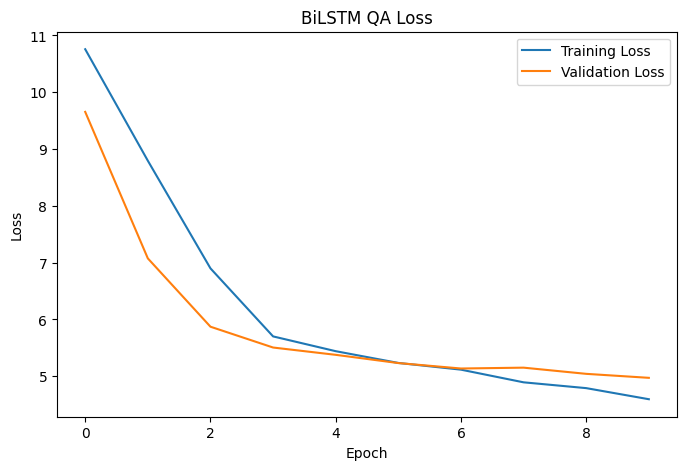

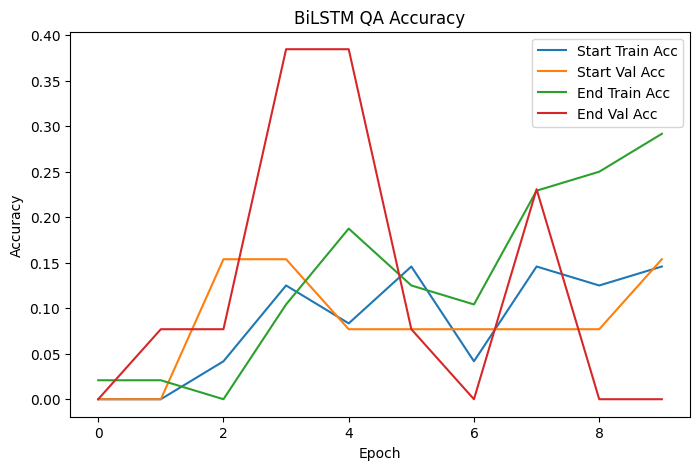

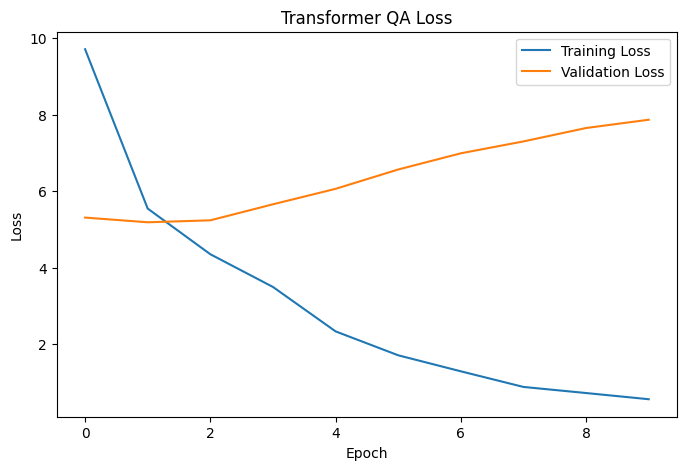

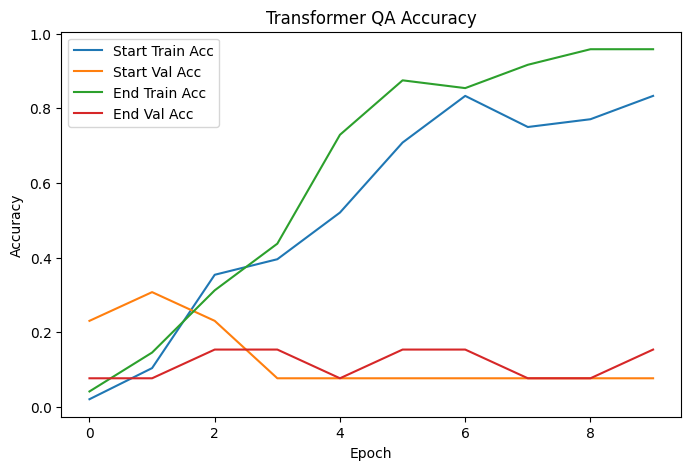

In [48]:
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["start_output_accuracy"], label="Start Train Acc")
    plt.plot(history.history["val_start_output_accuracy"], label="Start Val Acc")
    plt.plot(history.history["end_output_accuracy"], label="End Train Acc")
    plt.plot(history.history["val_end_output_accuracy"], label="End Val Acc")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


plot_history(history_bilstm, "BiLSTM QA")
plot_history(history_transformer, "Transformer QA")

Evaluate both models

In [49]:
print("BiLSTM Evaluation:")
bilstm_model.evaluate(
    X_test,
    {
        "start_output": y_start_test,
        "end_output": y_end_test
    }
)

print("Transformer Evaluation:")
transformer_model.evaluate(
    X_test,
    {
        "start_output": y_start_test,
        "end_output": y_end_test
    }
)

BiLSTM Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - end_output_accuracy: 0.0496 - end_output_loss: 2.1286 - loss: 4.8117 - start_output_accuracy: 0.0901 - start_output_loss: 2.5282 
Transformer Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - end_output_accuracy: 0.4596 - end_output_loss: 1.5545 - loss: 4.8510 - start_output_accuracy: 0.4804 - start_output_loss: 2.4371 


[4.793667316436768,
 2.2556753158569336,
 1.2489149570465088,
 0.47058823704719543,
 0.47058823704719543]

Inference function

In [50]:
def predict_answer(question, context, model, tokenizer, max_len=256):
    question_norm = normalize_arabic(question)
    context_norm = normalize_arabic(context)

    input_text = "[Q] " + question_norm + " [C] " + context_norm

    seq = tokenizer.texts_to_sequences([input_text])
    padded = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    start_probs, end_probs = model.predict(padded)

    start_idx = np.argmax(start_probs[0])
    end_idx = np.argmax(end_probs[0])

    tokens = input_text.split()

    if end_idx < start_idx:
        end_idx = start_idx

    predicted_tokens = tokens[start_idx:end_idx + 1]
    predicted_answer = " ".join(predicted_tokens)

    return predicted_answer, start_idx, end_idx

In [51]:
sample = df.iloc[0]

answer, start, end = predict_answer(
    sample["question"],
    sample["context"],
    bilstm_model,
    tokenizer,
    MAX_LEN
)

print("Question:", sample["question"])
print("True Answer:", sample["answer"])
print("Predicted Answer:", answer)
print("Start:", start)
print("End:", end)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Question: ما الأسلوب السردي؟
True Answer: السرد غير الخطي
Predicted Answer: والحاضر هذا يجعل القصه اكثر
Start: 15
End: 19


In [52]:

sample = df.iloc[10]

answer, start, end = predict_answer(
    sample["question"],
    sample["context"],
    transformer_model,
    tokenizer,
    MAX_LEN
)

print("Question:", sample["question"])
print("True Answer:", sample["answer"])
print("Predicted Answer:", answer)
print("Start:", start)
print("End:", end)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
Question: إلى أي شعبة ينتمي الأخطبوط؟
True Answer: الرخويات
Predicted Answer: الرخويات
Start: 9
End: 9
